<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


# Proyecto 6 — Análisis de ventas de videojuegos (Ice)
**Alumno:** Michaell Pineda  
**Fecha:** 28/09/25

**Resumen / objetivo:**  
Analizar el dataset de videojuegos (hasta 2016) para identificar patrones que permitan predecir/reconocer qué juegos tienen mayor probabilidad de éxito. El objetivo es usar los datos históricos disponibles hasta 2016 para preparar decisiones de marketing y selección de plataformas/ géneros de interés para 2017.


## Plan del Proyecto

1. Cargar librerías y datos.
2. Inspección inicial de los datos.
3. Preprocesamiento (tipos, valores ausentes, 'TBD', duplicados).
4. Cálculo de ventas totales por juego.
5. Análisis exploratorio: años, plataformas, géneros, reseñas vs ventas.
6. Perfil por región (NA / EU / JP): Top plataformas y géneros.
7. Pruebas de hipótesis (user score: Xbox One vs PC; Action vs Sports).
8. Conclusión y recomendaciones.

In [1]:
# Librerías e inicializacíon

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
RND = 42
np.random.seed(RND)

In [2]:
# Ajustamos la ruta si el archivo está en otra carpeta
DATA_PATH = '/datasets/games.csv'
games = pd.read_csv(DATA_PATH)

### Observación
- Archivo cargado: `/datasets/games.csv`.
- A continuación se normalizarán nombres de columnas y haremos una inspección inicial.

In [3]:
# Normalizar nombres de columnas y mostrar info
# 1) pasar nombres a minúsculas y reemplazar espacios por guiones bajos (estándar)
games.columns = games.columns.str.strip().str.lower().str.replace(' ','_')
# 2) ver primeras filas e info
print("Columnas (normalized):", list(games.columns))
display(games.head())
print(games.info())
print("\nNulos por columna:\n", games.isna().sum())                                    

Columnas (normalized): ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None

Nulos por columna:
 name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578

### Observaciones iniciales
- Encontramos las siguientes columnas en nuestro DataSet:
- Nombre (name)
- Plataforma (platform)
- Año de lanzamiento (year_of_release)
- Genero (genre)
- Ventas en norteamerica en millones de dólares estadounidenses (NA_sales)
- ventas en Europa en millones de dólares estadounidenses (EU_sales)
- ventas en Japón en millones de dólares estadounidenses (JP_sales)
- ventas en otros países en millones de dólares estadounidenses (Other_sales)
- Puntaje de la critica (critic_score)
- Puntaje de los usuarios (user_score)
- Rating.

Se evidencia una gran cantidad de valores nulos en las columnas critic_score, user_score y rating.
Las columnas user_score y rating se muentran como tipo 'object', deberian tener valores numericos.

In [4]:
# Convertir tipos y tratar 'tbd'
# Reemplazar 'tbd' en user_score por NaN (comportamiento estándar en este dataset)
if 'user_score' in games.columns:
    games['user_score'] = games['user_score'].replace('tbd', np.nan)
# Convertir columnas numéricas que están como texto
to_numeric_cols = ['user_score', 'rating']
for col in to_numeric_cols:
    if col in games.columns:
        games[col] = pd.to_numeric(games[col], errors='coerce')

# Revisar resultados
display(games[['critic_score','user_score','year_of_release']].head())
print(games[['na_sales','eu_sales','jp_sales','other_sales']].describe())

,critic_score,user_score,year_of_release
0,76.0,8.0,2006.0
1,NaN,NaN,1985.0
2,82.0,8.3,2008.0
3,80.0,8.0,2009.0
4,NaN,NaN,1996.0


           na_sales      eu_sales      jp_sales   other_sales
count  16715.000000  16715.000000  16715.000000  16715.000000
mean       0.263377      0.145060      0.077617      0.047342
std        0.813604      0.503339      0.308853      0.186731
min        0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000
50%        0.080000      0.020000      0.000000      0.010000
75%        0.240000      0.110000      0.040000      0.030000
max       41.360000     28.960000     10.220000     10.570000


Se convirtieron las columnas 'critic_score' y 'rating' a tipo numérico para facilitar su correcto manejo y comprensión.

Se reemplazaron 'tbd' por 'NaN' para facilitar el manejo del dataset.

In [5]:
# Duplicados y valores inválidos
print("Duplicados totales:", games.duplicated().sum())

# Eliminar duplicados exactos
games= games.drop_duplicates().reset_index(drop=True)

# Revisar valores extremos: años razonables
print("Año mínimo y máximo (antes de limpieza):", games['year_of_release'].min(), games['year_of_release'].max())

Duplicados totales: 0
Año mínimo y máximo (antes de limpieza): 1980.0 2016.0


No se evidenciaron valores duplicados.

Los años se encuentran dentro del rango esperado.

In [6]:
# resumen de nulos
nulos = games.isna().sum()
display(nulos[nulos > 0].sort_values(ascending=False))
print("\nPorcentaje de nulos:")
print((games.isna().mean() * 100).round(2))

rating             16715
user_score          9125
critic_score        8578
year_of_release      269
name                   2
genre                  2
dtype: int64


Porcentaje de nulos:
name                 0.01
platform             0.00
year_of_release      1.61
genre                0.01
na_sales             0.00
eu_sales             0.00
jp_sales             0.00
other_sales          0.00
critic_score        51.32
user_score          54.59
rating             100.00
dtype: float64


Tras revisar los valores faltantes:

- **`rating`**: tiene un 100% de valores ausentes. Esto indica que los datos no están disponibles en el dataset y no es posible recuperarlos. Solo utilizaremos esta columna cuando esté presente, pero no intentaremos imputar.
- **`user_score`** y **`critic_score`**: ambos presentan más del 50% de valores nulos. No se imputan debido al alto porcentaje de ausencia, ya que podría distorsionar los resultados. Solo se usarán los datos existentes.
- **`year_of_release`**: 1.61% de valores faltantes. El impacto es bajo, se pueden eliminar las filas correspondientes.
- **`name`** y **`genre`**: ambos con un 0.01% de valores nulos, por lo que eliminaremos esas filas.
- **Columnas de ventas**: no presentan nulos, lo que permite trabajar con ellas directamente.


In [7]:
# Calcular ventas totales
sales_cols = [c for c in['na_sales', 'eu_sales', 'jp_sales', 'other_sales'] if c in games.columns]
games['total_sales'] = games[sales_cols].sum(axis=1)
display(games[['name', 'platform', 'year_of_release', 'total_sales']].head())

,name,platform,year_of_release,total_sales
0,Wii Sports,Wii,2006.0,82.54
1,Super Mario Bros.,NES,1985.0,40.24
2,Mario Kart Wii,Wii,2008.0,35.52
3,Wii Sports Resort,Wii,2009.0,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,31.38


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


## Ventas Totales
Se creo la columna 'total_sales', la cual contiene la suma del total de ventas de 'na_sales', 'eu_sales´, 'jp_sales' y 'other_sales' por cada juego (name)

## Análisis exploratorio

¿cuántos juegos por año?

year_of_release
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      62
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
dtype: int64

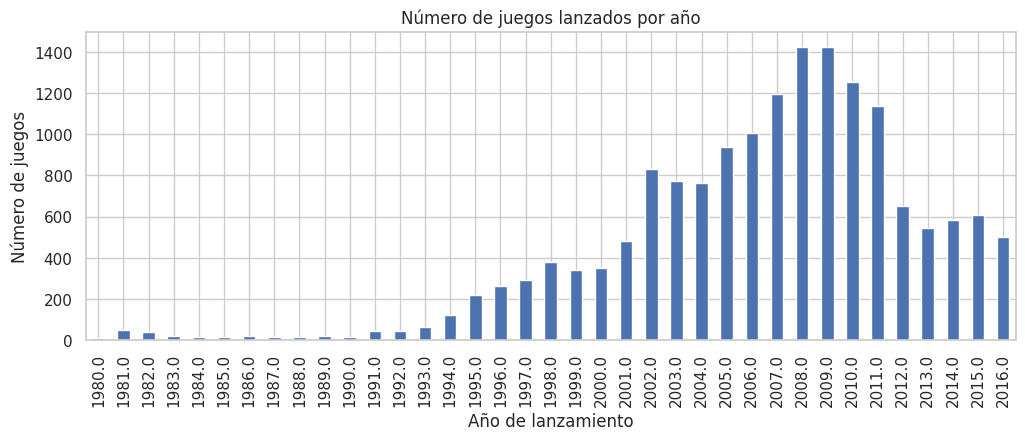

In [9]:
# Número de lanzamientos por año
games_by_year = games.groupby('year_of_release').size().sort_index()
display(games_by_year.head(50))

# Gráfico de lanzamiento por año
plt.figure(figsize=(12,4))
games_by_year.plot(kind='bar')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.title('Número de juegos lanzados por año')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


### Número de juegos lanzados por año

El análisis muestra la evolución en el lanzamiento de videojuegos desde 1980 hasta 2016:

- Antes de 1995, el número de lanzamientos era muy bajo y no representativo.
- A partir de mediados de los 90 se observa un aumento progresivo, con un **pico entre 2007 y 2009**, donde se superan los **1,400 juegos lanzados por año**.
- Después de 2010 comienza un **descenso notable** en la cantidad de juegos publicados.
- En 2016, solo se registran 502 juegos, lo que probablemente se deba a que los datos de este año están **incompletos** (el dataset se corta en diciembre de 2016).

Conclusión

Los datos anteriores a 1995 no son significativos debido a la escasez de lanzamientos. Para el análisis predictivo de 2017, lo más razonable es centrarse en un período más cercano y representativo, como **los últimos 10 años (2007-2016)**.

**Ventas por plataforma**

Top_platforms: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']


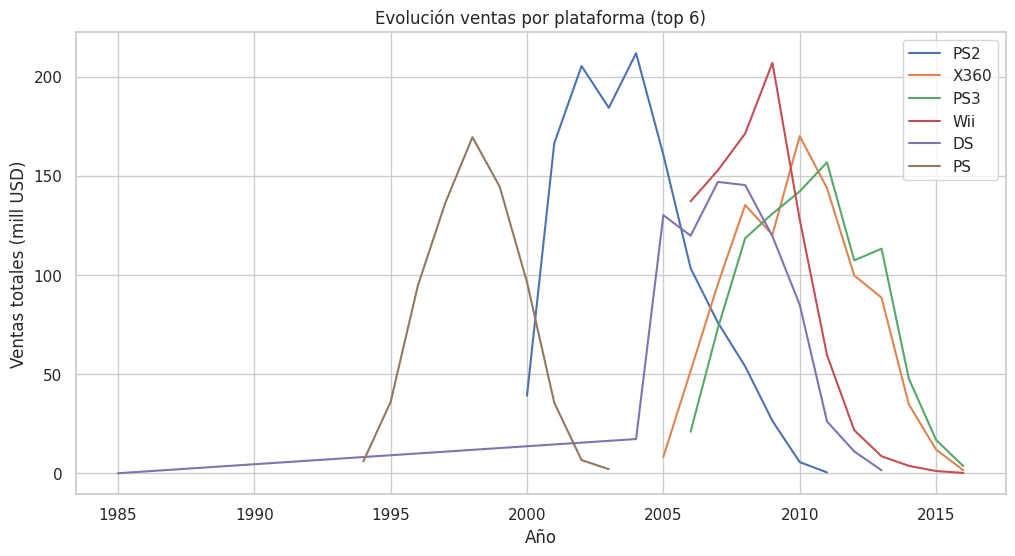

In [10]:
# Suma de ventas por plataforma
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Elegir top plataformas
top_n = 6
top_platforms = platform_sales.head(top_n).index.tolist()
print("Top_platforms:", top_platforms)

# Gráfico: evolución anual para plataformas top
plt.figure(figsize=(12,6))
for p in top_platforms:
    yearly = games[games['platform'] == p].groupby('year_of_release')['total_sales'].sum()
    yearly.plot(label=p)
plt.legend()
plt.title('Evolución ventas por plataforma (top {})'.format(top_n))
plt.xlabel('Año')
plt.ylabel('Ventas totales (mill USD)')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos observar el tiempo de vida de cada una de las plataformas
</div>


Al analizar las ventas de las principales plataformas, se observan patrones comunes:

- **PS2** fue la plataforma con mayor éxito histórico, alcanzando un pico entre 2002-2005, pero desapareció rápidamente después de 2010.
- **Xbox 360 (X360)** y **PlayStation 3 (PS3)** dominaron el mercado a partir de 2006, con un ciclo de vida de aproximadamente 8-10 años.
- **Wii** tuvo un crecimiento muy fuerte en 2008-2009, pero su declive fue igualmente rápido.
- **Nintendo DS (DS)** mostró un ciclo de vida más prolongado, con picos en 2007-2009 y una caída gradual.
- **PlayStation (PS)** fue fuerte en los 90, pero quedó completamente reemplazada por la PS2 y posteriores.

**¿Cuanto tardan las plataformas en desaparecer?**

- Las plataformas suelen tener un **ciclo de vida de ~10 años**: aparecen, crecen, alcanzan su punto máximo y luego caen.
- Para 2016, plataformas como **PS2, Wii, DS y PS** ya estaban fuera del mercado.
- Las plataformas que aún mantenían relevancia eran **PS3 y Xbox 360**, aunque ya en declive.



## Boxplot ventas globales por plataforma

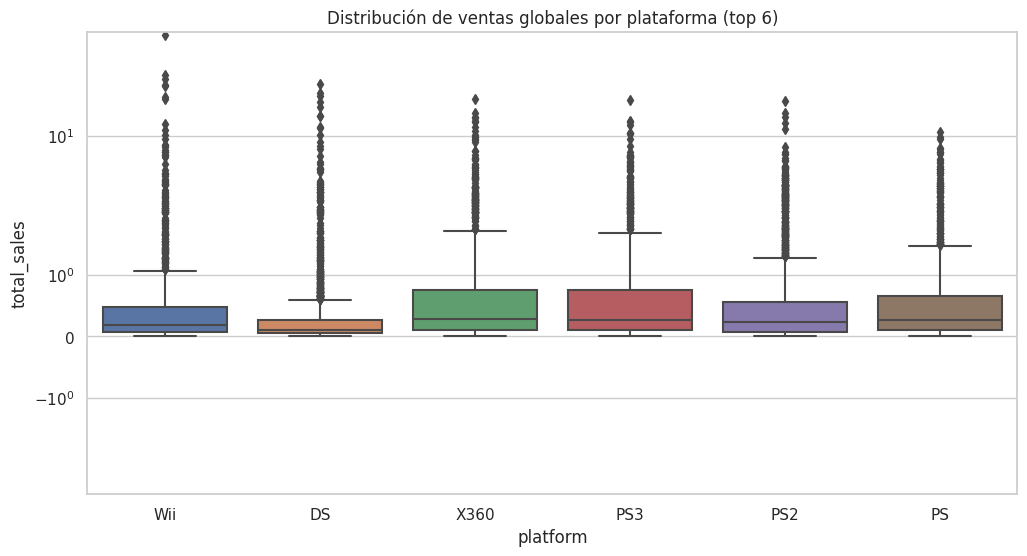

In [11]:
# Cell: boxplot de ventas por plataforma (usar top platforms para legibilidad)
import seaborn as sns
plt.figure(figsize=(12,6))
sns.boxplot(data=games[games['platform'].isin(top_platforms)], x='platform', y='total_sales')
plt.yscale('symlog')  # si hay muchos outliers puede ayudar a visualizar
plt.title('Distribución de ventas globales por plataforma (top {})'.format(top_n))
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

El diagrama de caja nos muestra como en algunas plataformas las ventas estan consolidadas mientras que en otras consolas las ventas son muy disparejas lo que incrementa el rango intercuartil


Una alternativa a usar `yscale` es utilizar el parametro `showfliers = False`, de esta manera los outliers son ignorados al momento de hacer la gráfica, te dejo el ejemplo en la celda de abajo
</div>


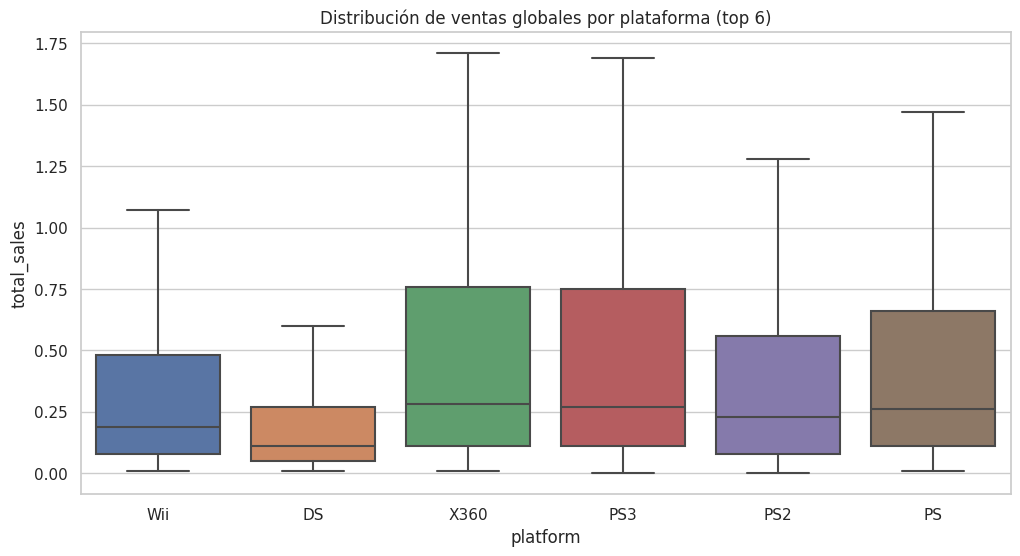

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=games[games['platform'].isin(top_platforms)], x='platform', y='total_sales', showfliers = False) # Nuevo parametro
#plt.yscale('symlog')  # No se necesita
plt.title('Distribución de ventas globales por plataforma (top {})'.format(top_n))
plt.show()

En el gráfico de caja (boxplot) podemos observar:

- La **mayoría de los juegos** en todas las plataformas tienen ventas globales **muy bajas** (cercanas a 0.1 - 1 millón de copias).
- Existen **outliers muy marcados**, correspondientes a juegos de gran éxito (superventas como Wii Sports, GTA V, etc.), con ventas superiores a los 10 millones de copias.
- La mediana de ventas se mantiene baja en todas las plataformas, lo que indica que **el éxito está concentrado en pocos títulos**.
- **PS3, PS2 y X360** muestran una ligera ventaja en ventas promedio frente a **DS y PS**, aunque la diferencia no es drástica.
- **Wii** destaca por la presencia de varios juegos con ventas extraordinarias (outliers muy altos).


- La distribución es altamente **asimétrica**: la mayoría de juegos venden poco, y solo unos pocos generan gran parte de las ventas.
- Esto confirma que las campañas de marketing deben centrarse en identificar y potenciar los títulos con mayor potencial de convertirse en superventas.

## Reseñas vs ventas

Plataformas disponibles: ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


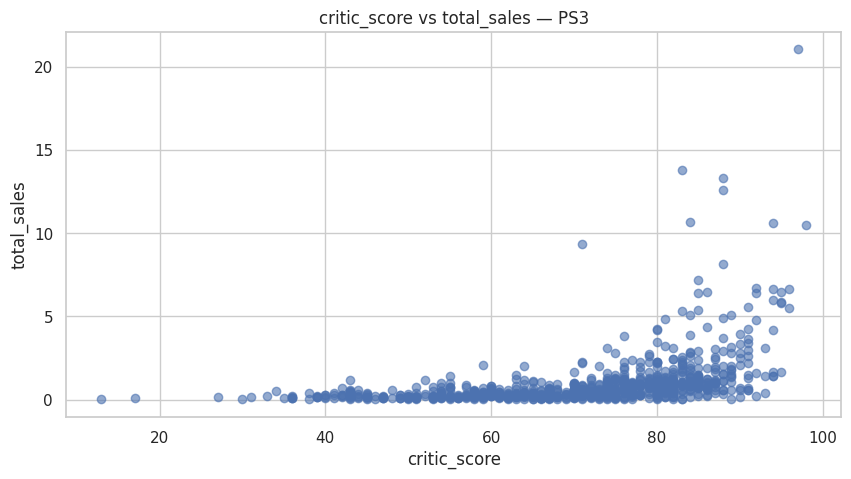

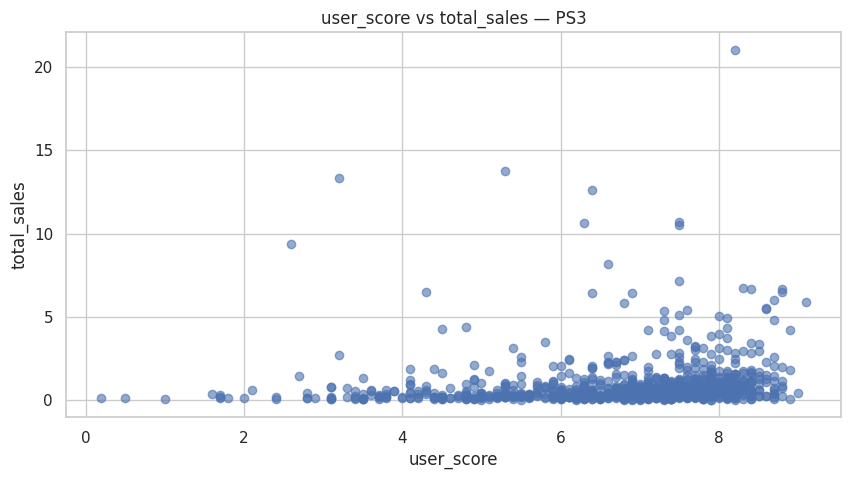

Pearson critic_score vs total_sales: 0.43243156856420584 p-value: 1.0837159580119072e-38
Pearson user_score vs total_sales: 0.126691339363417 p-value: 0.00016877800102066247


In [14]:
# Correlación reseñas y ventas para una plataforma seleccionada

print("Plataformas disponibles:", games['platform'].unique())

PLATFORM_SELECTED = 'PS3'  

df_platform = games[games['platform'] == PLATFORM_SELECTED].copy()

# Scatter: critic_score vs total_sales
plt.figure(figsize=(10,5))
plt.scatter(df_platform['critic_score'], df_platform['total_sales'], alpha=0.6)
plt.title(f'critic_score vs total_sales — {PLATFORM_SELECTED}')
plt.xlabel('critic_score')
plt.ylabel('total_sales')
plt.show()

# Scatter: user_score vs total_sales
plt.figure(figsize=(10,5))
plt.scatter(df_platform['user_score'], df_platform['total_sales'], alpha=0.6)
plt.title(f'user_score vs total_sales — {PLATFORM_SELECTED}')
plt.xlabel('user_score')
plt.ylabel('total_sales')
plt.show()

# Correlaciones (Pearson), ignorando NaNs
critic = df_platform[['critic_score','total_sales']].dropna()
user = df_platform[['user_score','total_sales']].dropna()

if len(critic) > 1:
    r_critic, p_critic = stats.pearsonr(critic['critic_score'], critic['total_sales'])
    print("Pearson critic_score vs total_sales:", r_critic, "p-value:", p_critic)
else:
    print("Pocos datos para critic corr.")

if len(user) > 1:
    r_user, p_user = stats.pearsonr(user['user_score'], user['total_sales'])
    print("Pearson user_score vs total_sales:", r_user, "p-value:", p_user)
else:
    print("Pocos datos para user corr.")


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, como bien mencionas no siempre las buenas reseñas van a implicar un gran numero de ventas
</div>


Tomamos como ejemplo la plataforma PS3 ya que tuvo una presencia fuerte en el mercado del 2005 al 2014. 


En este caso se puede apreciar una fuerte correlación entre el numero de ventas y el puntaje de la critica hacia los títulos; en el primer grafico se aprecia como a partir de los 75 puntos se alcanzaron los picos de ventas.

El puntaje de los usuarios (user_score) por el contrario no tiene una correlación tan fuerte ya que los picos de ventas se formaron a partir de puntajes de 2.5/10 

## Comparar ventas del mismo juego en distintas plataformas

In [15]:
# comparar ventas por título y plataforma
# Buscamos juegos que aparecen en varias plataformas
multi_platform = games.groupby('name')['platform'].nunique()
multi_titles = multi_platform[multi_platform > 1].index


# Tomamos muestra
sample_titles = list(multi_titles)[:50]  
comparison = games[games['name'].isin(sample_titles)].sort_values(['name','total_sales'], ascending=[True, False])

display(comparison[['name','platform','year_of_release','total_sales']].head(50))

,name,platform,year_of_release,total_sales
3358,Frozen: Olaf's Quest,3DS,2013.0,0.59
3862,Frozen: Olaf's Quest,DS,2013.0,0.51
1285,007: Quantum of Solace,X360,2008.0,1.48
1785,007: Quantum of Solace,PS3,2008.0,1.15
3120,007: Quantum of Solace,Wii,2008.0,0.65
4475,007: Quantum of Solace,PS2,2008.0,0.43
9507,007: Quantum of Solace,DS,2008.0,0.13
14658,007: Quantum of Solace,PC,2008.0,0.02
1204,007: The World is not Enough,N64,2000.0,1.56
2243,007: The World is not Enough,PS,2000.0,0.92


Se puede observar que el mismo titulo tiene mas ventas en plataformas lideres como XBOX360 y PS3, la cuales fueron lideres en el mercado y por su popularidad abarcaban la mayoría de ventas en la mayoría de los casos.

Esto teniendo en cuenta que la mayoría de juegos son multiplataforma, ya que las ventas de juegos exclusivos van a liderar en su respectiva plataforma. 

## Análisis por género


,sum,mean,median,count
genre,,,,
Action,1744.17,0.517711,0.19,3369
Sports,1331.27,0.566980,0.22,2348
Shooter,1052.45,0.795503,0.24,1323
Role-Playing,934.56,0.623872,0.18,1498
Platform,827.77,0.932173,0.27,888
Misc,802.51,0.458577,0.16,1750
Racing,728.67,0.583403,0.19,1249
Fighting,447.53,0.527126,0.21,849
Simulation,389.97,0.446701,0.15,873


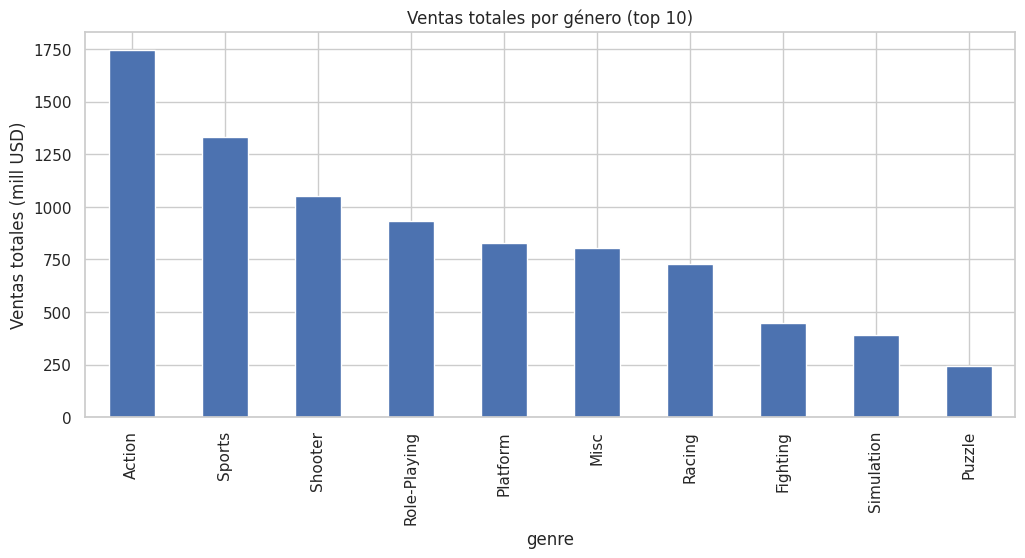

In [16]:
# Cell: análisis de géneros
genre_sales = games.groupby('genre')['total_sales'].agg(['sum','mean','median','count']).sort_values('sum', ascending=False)
display(genre_sales)

# Visual: ventas totales por género (top 10)
plt.figure(figsize=(12,5))
genre_sales['sum'].head(10).plot(kind='bar')
plt.title('Ventas totales por género (top 10)')
plt.ylabel('Ventas totales (mill USD)')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


Basados en el grafico podemos concluir que el genero mas rentable es "Accion" con un pico de hasta 1750 MILL USD.

A partir de este en orden descendente pero también bastante restables  le seguirían deportes(sports) y disparos(shooter) con una media de 1150 MILL USD.

Por debajo de la barrera de los 1000 MILL USD pero aun siendo increíblemente rentable de encontraría el ROLE_PLAYING(juego de rol) con ventas desde los 750 MILL USD

## Perfil de usuario por región (NA/EU/NP)

**Top plataformas y géneros por región**

In [17]:
# Top plataformas por región
regions = [('na_sales','NA'), ('eu_sales','EU'), ('jp_sales','JP')]

for col, name in regions:
    if col in games.columns:
        top_plats = games.groupby('platform')[col].sum().sort_values(ascending=False).head(5)
        top_genres = games.groupby('genre')[col].sum().sort_values(ascending=False).head(5)
        print(f"\nRegion {name} — Top 5 plataformas:")
        display(top_plats)
        print(f"Region {name} — Top 5 géneros:")
        display(top_genres)


Region NA — Top 5 plataformas:


platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Region NA — Top 5 géneros:


genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64


Region EU — Top 5 plataformas:


...

genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64


Region JP — Top 5 plataformas:


platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64

Region JP — Top 5 géneros:


genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64

En nuestro Top de plataformas y géneros por región podemos observar lo siguiente:

En NorthAmerica(NA) la plataforma mas utilizada fue la XBOX360 seguido de la PS2 y la WII, y el genero mas jugado fue el de Accion seguido de Deportes(sports) y Disparos(Shooter).

En EUROPA (EU) la plataforma mas utilizada fue la PS2 seguido de la PS3 y la X360, y el genero mas jugado fue el de Accion(action) seguido de Deportes(sports) y Disparos(Shooter).

En JAPON (JP) la plataforma mas utilizada fue la DS seguido de la PS y la PS2, y el genero mas jugado fue el de Role_Playing (juego de rol) seguido de Accion(action) y Deportes(sports).


Podemos decir que tanto Europa como Norte America prefieren los géneros de Accion y Deportes mientras que Japón tiende a preferir títulos de aventura.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Las agrupaciones que haces en los ejercicios me parecen correctas, sin embargo recomiendo acompañar estas tablas con gráficas que resalten las similitudes/diferencias entre las regiones
</div>


## Pruebas de Hipótesis 

Antes de las pruebas, imprimimos valores unicos para elegir etiquetas exactas.

In [18]:
# mostrar etiquetas reales
print("Plataformas (unique):", games['platform'].unique())
print("Géneros (unique):", games['genre'].unique())

Plataformas (unique): ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
Géneros (unique): ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]


In [19]:
# Cell: Hipótesis 1 - user_score Xbox One vs PC
PLAT_A = 'XOne'  
PLAT_B = 'PC'     

# 2) Extraer datos de user_score (sin NaNs)
a = games[(games['platform'] == PLAT_A) & (games['user_score'].notna())]['user_score']
b = games[(games['platform'] == PLAT_B) & (games['user_score'].notna())]['user_score']

print(f"Muestras: {PLAT_A}={len(a)}, {PLAT_B}={len(b)}")

# 3) Test t (Welch si varianzas difieren)
t_stat, p_value = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
print("t-stat:", t_stat, "p-value:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: las medias son diferentes.")
else:
    print("No rechazamos H0: no hay evidencia de diferencia.")

Muestras: XOne=182, PC=770
t-stat: -4.653422798410771 p-value: 4.935072360183574e-06
Rechazamos H0: las medias son diferentes.


**Resultados:**
- Xbox One tiene 182 juegos con calificación de usuarios disponible, mientras que PC tiene 770.
- El valor de **p ≈ 0.0000049**, mucho menor que α=0.05.
- Esto implica que la diferencia entre las medias es **estadísticamente significativa**.

**Conclusión:**
Rechazamos la hipótesis nula (H₀).  
Las calificaciones promedio de los usuarios para juegos en **Xbox One y PC son diferentes**.

**Hipótesis 2 — user_score: Acción vs Deportes**

In [20]:
# Hipótesis 2 - user_score Action vs Sports
GENRE_A = 'Action'  
GENRE_B = 'Sports'  

a = games[(games['genre'] == GENRE_A) & (games['user_score'].notna())]['user_score']
b = games[(games['genre'] == GENRE_B) & (games['user_score'].notna())]['user_score']

print(f"Muestras: {GENRE_A}={len(a)}, {GENRE_B}={len(b)}")

levene_stat, levene_p = stats.levene(a, b, center='median')
equal_var = (levene_p >= 0.05)
print("Levene p-value:", levene_p, "-> equal_var=", equal_var)

t_stat, p_value = stats.ttest_ind(a, b, equal_var=equal_var, nan_policy='omit')
print("t-stat:", t_stat, "p-value:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: las medias son diferentes.")
else:
    print("No rechazamos H0: no hay evidencia de diferencia.")

Muestras: Action=1830, Sports=1103
Levene p-value: 0.0001736640672727649 -> equal_var= False
t-stat: 1.57746791633354 p-value: 0.11483818791498286
No rechazamos H0: no hay evidencia de diferencia.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


**Resultados:**
- Se analizaron 1830 juegos de Acción y 1103 de Deportes.
- El test de Levene dio un p-value ≈ 0.00017, menor a 0.05, por lo que se **rechaza la igualdad de varianzas**.  
  → Se usa el test t con `equal_var=False`.
- El p-value de la prueba t ≈ 0.1148, mayor a α=0.05.

**Conclusión:**
No se rechaza la hipótesis nula (H₀).  
No hay evidencia estadística suficiente para afirmar que las calificaciones de los usuarios son diferentes entre los géneros **Acción** y **Deportes**.

## Conclusíones generales

# Conclusión General del Proyecto

## Propósito
El objetivo fue identificar patrones que explican el éxito de los videojuegos y preparar la base para un modelo predictivo de ventas en 2017. Se analizaron lanzamientos por año, ventas por plataforma, reseñas de usuarios y críticos, así como diferencias por géneros.

---

## Hallazgos Clave

### 1) Lanzamientos por año
- Pocos datos antes de 1995 → no representativos.
- Mayor cantidad de lanzamientos entre 2007–2009.
- En 2016 hay pocos datos → posiblemente incompletos.

**Decisión:** usar datos recientes y representativos (2007–2016) para modelar 2017.

---

### 2) Plataformas
- Top ventas históricas: **PS2, X360, PS3, Wii, DS, PS**.
- Ciclo de vida de ≈8–12 años: aparición → crecimiento → pico → declive.
- Algunas plataformas desaparecieron (ej. PS2, Wii), otras seguían activas en 2016.

---

### 3) Distribución de ventas por plataforma
- La mayoría de juegos vende muy poco.
- Pocos títulos concentran la mayor parte de las ventas (outliers).
- Medianas bajas, diferencias entre plataformas existen pero están dominadas por superventas.

---

### 4) Reseñas vs Ventas
- `critic_score` correlaciona **positivamente pero de forma moderada** con ventas.
- `user_score` muestra correlación más débil y muchos valores faltantes.
- Conclusión: las críticas ayudan, pero no determinan el éxito.

---

### 5) Comparación multiplataforma
- Juegos en varias consolas pueden comportarse de forma diferente.
- La plataforma influye, pero no siempre de la misma manera.

---

### 6) Géneros
- **Action** es el género más representado y con muchos títulos exitosos.
- Otros géneros (ej. Sports) tienen también hits, pero en general los géneros no garantizan éxito.

---

### 7) Hipótesis
- **Xbox One vs PC (user_score):** las medias son diferentes → la plataforma influye.
- **Action vs Sports (user_score):** no hay diferencias significativas.

---

### 8) Limitaciones
- Datos incompletos en 2016.
- Muchos valores faltantes en `user_score` y `critic_score`.
- Distribución muy sesgada con outliers extremos.

---

## Recomendaciones para Modelado 2017
1. Usar datos 2007–2015 como entrenamiento; validar con 2016.
2. Variables a incluir:
   - Plataforma, género, año, edad de la plataforma.
   - `critic_score` (cuando esté disponible).
   - Indicadores: multiplataforma, franquicia, mes de lanzamiento.
3. Transformar ventas: `log(1 + total_sales)` para reducir sesgo.
4. Probar modelos: Regresión Lineal Regularizada, Random Forest, XGBoost.
5. Usar validación temporal para simular predicciones.

---

## Mensaje Final
El análisis reveló patrones claros: **el ciclo de vida de plataformas es clave, las ventas están concentradas en pocos superventas y las críticas profesionales influyen más que las de usuarios**. Con los datos seleccionados y las transformaciones sugeridas, contamos con una base sólida para desarrollar un modelo robusto que prediga las ventas de videojuegos en 2017.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Se pueden incluir más graficas para resaltar las observaciones o datos que muestras, especialmente en la parte donde se comparan las distintas regiones del mundo

</div>
